<a href="https://colab.research.google.com/github/Jslxh/mlops_tr/blob/main/ZENTRIXS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_excel("/content/worker_health_dataset.xlsx")
df.head()

,worker_id,age,department,shift_duration_hrs,reported_symptoms,diagnosis,ppe_compliance_score,audio_alert_flag,risk_level,outcome
0,W1000,48,Paint Shop,7.4,minor knee pain after long standing shift,Dehydration (mild),0.79,0,LOW,First Aid
1,W1001,51,Boiler Room,6.2,"occasional dizziness, light sensitivity",Dehydration (mild),0.73,0,LOW,Rest and Resume
2,W1002,31,Assembly Line,8.7,"muscle soreness, mild back ache",Mild Allergic Reaction,0.94,0,LOW,First Aid
3,W1003,58,Heavy Machinery,8.8,minor knee pain after long standing shift,Mild Allergic Reaction,0.91,0,LOW,No Treatment Required
4,W1004,54,Boiler Room,12.2,"heat stroke symptoms, no sweating, skin hot an...",Heat Stroke,0.33,1,HIGH,ICU Admission


In [6]:
print(df.shape)

(1000, 10)


In [7]:
df = df.drop(["worker_id","reported_symptoms","diagnosis","outcome"],axis = 1)
df.head()

,age,department,shift_duration_hrs,ppe_compliance_score,audio_alert_flag,risk_level
0,48,Paint Shop,7.4,0.79,0,LOW
1,51,Boiler Room,6.2,0.73,0,LOW
2,31,Assembly Line,8.7,0.94,0,LOW
3,58,Heavy Machinery,8.8,0.91,0,LOW
4,54,Boiler Room,12.2,0.33,1,HIGH


In [8]:
df = pd.get_dummies(df,columns=["department","risk_level"], drop_first = True)
df.head()

,age,shift_duration_hrs,ppe_compliance_score,audio_alert_flag,department_Boiler Room,department_Chemical Processing,department_Electrical Unit,department_Foundry,department_Heavy Machinery,department_Mining Section,department_Paint Shop,department_Warehouse,department_Welding Unit,risk_level_LOW,risk_level_MEDIUM
0,48,7.4,0.79,0,False,False,False,False,False,False,True,False,False,True,False
1,51,6.2,0.73,0,True,False,False,False,False,False,False,False,False,True,False
2,31,8.7,0.94,0,False,False,False,False,False,False,False,False,False,True,False
3,58,8.8,0.91,0,False,False,False,False,True,False,False,False,False,True,False
4,54,12.2,0.33,1,True,False,False,False,False,False,False,False,False,False,False


In [9]:
X = df.drop("ppe_compliance_score", axis=1)
y = df["ppe_compliance_score"]

print(X.shape)
print(y.shape)

(1000, 14)
(1000,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(800, 14) (200, 14)


In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [12]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[0.8579653  0.85811647 0.22148663 0.8384289  0.23640744]


In [13]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 0.00978559009543734
R2 Score: 0.7896926017698318


In [14]:
model.coef_

array([-3.13388070e-04, -3.52051256e-03,  9.56908126e-03, -8.14456267e-03,
       -1.33357413e-02,  7.24837094e-03, -7.21136986e-03, -1.81434762e-02,
        1.00942304e-02,  6.81727114e-03,  1.95696301e-02, -1.28685806e-02,
        6.11597828e-01,  3.26552506e-01])

In [15]:
model.intercept_

np.float64(0.2804379395641788)

VISUALIZATION

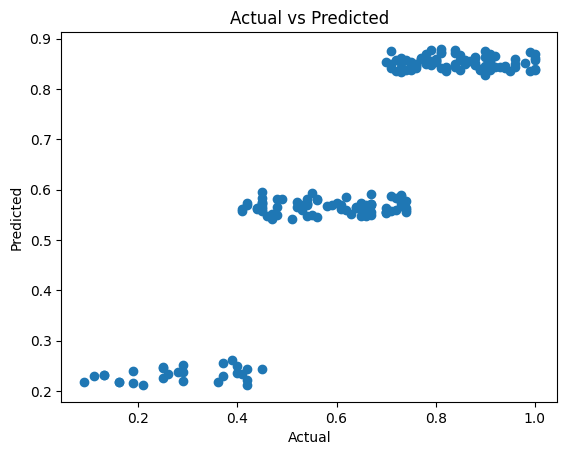

In [16]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

SAVE MODEL USING PICKLE

In [17]:
import pickle

In [18]:
with open('zentrix_pkl','wb') as file:
  pickle.dump(model,file)

LOADING THE SAVED MODEL

In [19]:
with open('zentrix_pkl','rb') as file:
  zp = pickle.load(file)

In [20]:
zp.coef_

array([-3.13388070e-04, -3.52051256e-03,  9.56908126e-03, -8.14456267e-03,
       -1.33357413e-02,  7.24837094e-03, -7.21136986e-03, -1.81434762e-02,
        1.00942304e-02,  6.81727114e-03,  1.95696301e-02, -1.28685806e-02,
        6.11597828e-01,  3.26552506e-01])

In [21]:
zp.intercept_

np.float64(0.2804379395641788)

In [22]:
zp.predict(X_test)

array([0.8579653 , 0.85811647, 0.22148663, 0.8384289 , 0.23640744,
       0.871211  , 0.54770071, 0.56970357, 0.55645925, 0.56602196,
       0.83567435, 0.84404745, 0.85293711, 0.59480276, 0.84139266,
       0.55951636, 0.55835238, 0.86315605, 0.55991468, 0.56896889,
       0.84917701, 0.86872312, 0.84666935, 0.56273987, 0.83310539,
       0.54751558, 0.54137288, 0.8520673 , 0.56967307, 0.55217365,
       0.56220581, 0.8555221 , 0.84750123, 0.5585911 , 0.55659887,
       0.5487182 , 0.55845332, 0.83611919, 0.56288222, 0.85149024,
       0.86226376, 0.54224388, 0.83815914, 0.84984309, 0.8419285 ,
       0.55174836, 0.87695724, 0.23347096, 0.2370711 , 0.85127105,
       0.57963901, 0.54763656, 0.86080768, 0.24321062, 0.59233788,
       0.84499413, 0.86246524, 0.57304936, 0.57174375, 0.82719963,
       0.21657925, 0.57002276, 0.25557641, 0.55509498, 0.57123765,
       0.23120079, 0.58181093, 0.55638872, 0.21254387, 0.56990269,
       0.83714664, 0.57389769, 0.85794853, 0.56460189, 0.85435

SAVE TRAINED MODEL USING JOBLIB

In [25]:
import joblib

In [26]:
joblib.dump(model,'zentrix_joblib')

['zentrix_joblib']

LOAD SAVED MODEL

In [27]:
mj = joblib.load('zentrix_joblib')

In [28]:
mj.coef_

array([-3.13388070e-04, -3.52051256e-03,  9.56908126e-03, -8.14456267e-03,
       -1.33357413e-02,  7.24837094e-03, -7.21136986e-03, -1.81434762e-02,
        1.00942304e-02,  6.81727114e-03,  1.95696301e-02, -1.28685806e-02,
        6.11597828e-01,  3.26552506e-01])

In [29]:
mj.intercept_

np.float64(0.2804379395641788)

In [31]:
mj.predict(X_test)

array([0.8579653 , 0.85811647, 0.22148663, 0.8384289 , 0.23640744,
       0.871211  , 0.54770071, 0.56970357, 0.55645925, 0.56602196,
       0.83567435, 0.84404745, 0.85293711, 0.59480276, 0.84139266,
       0.55951636, 0.55835238, 0.86315605, 0.55991468, 0.56896889,
       0.84917701, 0.86872312, 0.84666935, 0.56273987, 0.83310539,
       0.54751558, 0.54137288, 0.8520673 , 0.56967307, 0.55217365,
       0.56220581, 0.8555221 , 0.84750123, 0.5585911 , 0.55659887,
       0.5487182 , 0.55845332, 0.83611919, 0.56288222, 0.85149024,
       0.86226376, 0.54224388, 0.83815914, 0.84984309, 0.8419285 ,
       0.55174836, 0.87695724, 0.23347096, 0.2370711 , 0.85127105,
       0.57963901, 0.54763656, 0.86080768, 0.24321062, 0.59233788,
       0.84499413, 0.86246524, 0.57304936, 0.57174375, 0.82719963,
       0.21657925, 0.57002276, 0.25557641, 0.55509498, 0.57123765,
       0.23120079, 0.58181093, 0.55638872, 0.21254387, 0.56990269,
       0.83714664, 0.57389769, 0.85794853, 0.56460189, 0.85435